## Import Needed Package

In [ ]:
!pip install -q imbalanced-learn xgboost lightgbm

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from collections import Counter
from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, auc, roc_curve
)

from imblearn.combine import SMOTETomek

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
import xgboost as xgb
import lightgbm as lgb

sns.set(style='whitegrid')
RANDOM_STATE = 42

def show_md(title):
    display(Markdown(f"### {title}"))

def plot_confusion(cm, title="Confusion Matrix"):
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

## Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/notes/data-bank.csv')
df.columns = df.columns.str.strip()

print("Ukuran dataset:", df.shape)
display(df.head())

Ukuran dataset: (6819, 96)


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


## Data Understanding

Target Variable: 'Bankrupt?'
Keterangan:
- 1 = Bank dinyatakan bangkrut
- 0 = Bank masih beroperasi (sehat)

Distribusi target variable:
Bankrupt?
0    6599
1     220
Name: count, dtype: int64


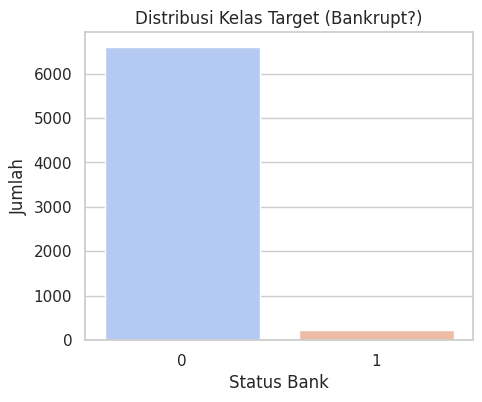

In [ ]:
# 🎯 1. Target Variable
print("Target Variable: 'Bankrupt?'")
print("Keterangan:")
print("- 1 = Bank dinyatakan bangkrut")
print("- 0 = Bank masih beroperasi (sehat)\n")

print("Distribusi target variable:")
print(df['Bankrupt?'].value_counts())

plt.figure(figsize=(5,4))
sns.countplot(x='Bankrupt?', data=df, hue='Bankrupt?', legend=False, palette='coolwarm')
plt.title('Distribusi Kelas Target (Bankrupt?)')
plt.xlabel('Status Bank')
plt.ylabel('Jumlah')
plt.show()

In [ ]:
# 🔍 2. Cek struktur & ringkasan data
print("\nInfo Dataset:")
print(df.info())

print("\nStatistik Deskriptif:")
display(df.describe().T.head(10))  # tampilkan 10 kolom pertama saja biar ringkas


Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Bankrupt?                                                6819 non-null   int64  
 1   ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2   ROA(A) before interest and % after tax                   6819 non-null   float64
 3   ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4   Operating Gross Margin                                   6819 non-null   float64
 5   Realized Sales Gross Margin                              6819 non-null   float64
 6   Operating Profit Rate                                    6819 non-null   float64
 7   Pre-tax net Interest Rate                                6819 non-null   float64
 8   After-tax net

,count,mean,std,min,25%,50%,75%,max
Bankrupt?,6819.0,0.032263,0.176710,0.0,0.000000,0.000000,0.000000,1.0
ROA(C) before interest and depreciation before interest,6819.0,0.505180,0.060686,0.0,0.476527,0.502706,0.535563,1.0
ROA(A) before interest and % after tax,6819.0,0.558625,0.065620,0.0,0.535543,0.559802,0.589157,1.0
ROA(B) before interest and depreciation after tax,6819.0,0.553589,0.061595,0.0,0.527277,0.552278,0.584105,1.0
Operating Gross Margin,6819.0,0.607948,0.016934,0.0,0.600445,0.605997,0.613914,1.0
Realized Sales Gross Margin,6819.0,0.607929,0.016916,0.0,0.600434,0.605976,0.613842,1.0
Operating Profit Rate,6819.0,0.998755,0.013010,0.0,0.998969,0.999022,0.999095,1.0
Pre-tax net Interest Rate,6819.0,0.797190,0.012869,0.0,0.797386,0.797464,0.797579,1.0
After-tax net Interest Rate,6819.0,0.809084,0.013601,0.0,0.809312,0.809375,0.809469,1.0
Non-industry income and expenditure/revenue,6819.0,0.303623,0.011163,0.0,0.303466,0.303525,0.303585,1.0



Top 10 fitur dengan korelasi tertinggi terhadap 'Bankrupt?':
Bankrupt?                              1.000000
Debt ratio %                           0.250161
Current Liability to Assets            0.194494
Borrowing dependency                   0.176543
Current Liability to Current Assets    0.171306
Liability to Equity                    0.166812
Current Liabilities/Equity             0.153828
Current Liability to Equity            0.153828
Liability-Assets Flag                  0.139212
Total expense/Assets                   0.139049
Name: Bankrupt?, dtype: float64


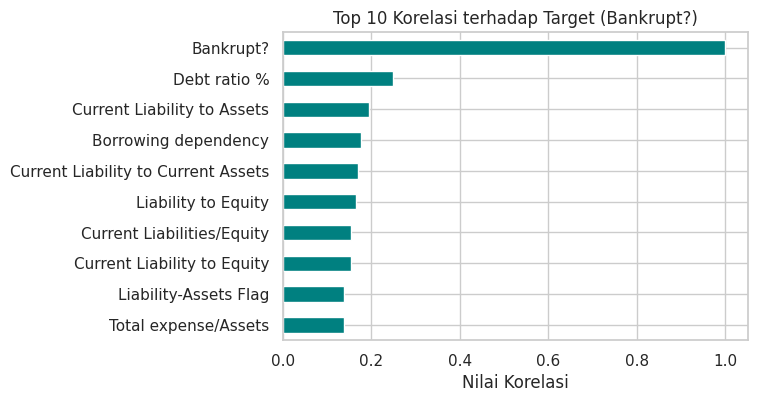

In [ ]:
# 🔗 3. Korelasi antar variabel terhadap target
# ==========================================================
corr = df.corr(numeric_only=True)['Bankrupt?'].sort_values(ascending=False)
print("\nTop 10 fitur dengan korelasi tertinggi terhadap 'Bankrupt?':")
print(corr.head(10))

plt.figure(figsize=(6,4))
corr.head(10).plot(kind='barh', color='teal')
plt.title('Top 10 Korelasi terhadap Target (Bankrupt?)')
plt.xlabel('Nilai Korelasi')
plt.gca().invert_yaxis()
plt.show()

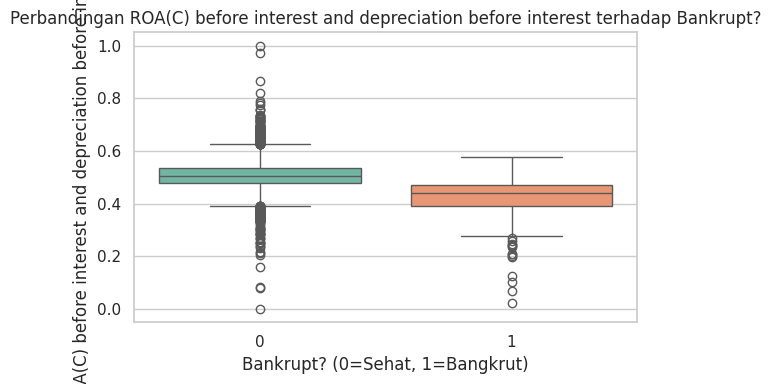

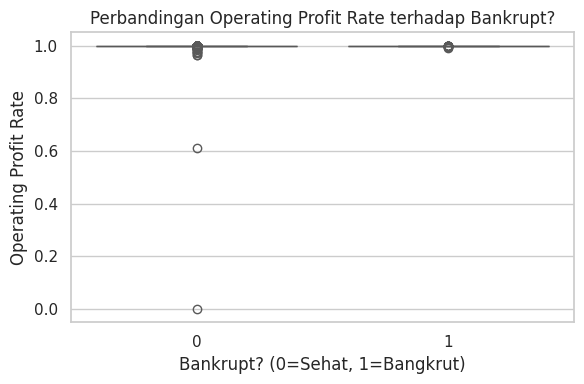

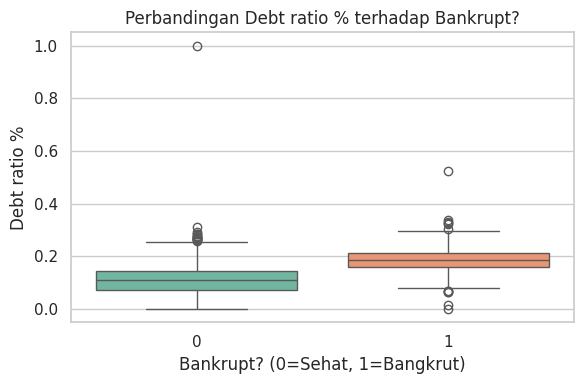

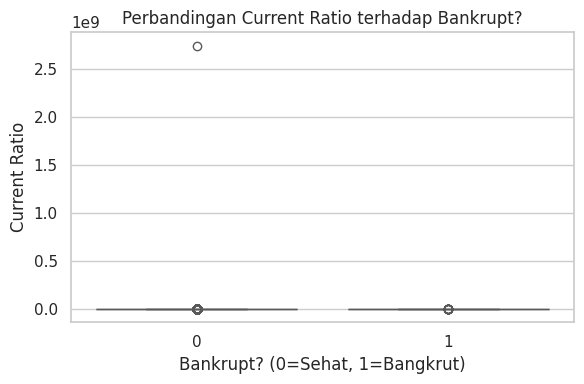

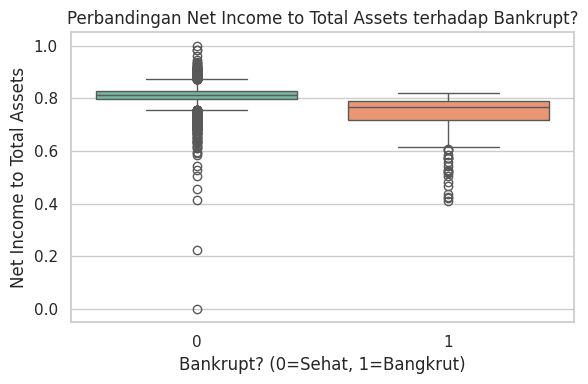

In [ ]:
# 📉 4. Visualisasi hubungan 2 variabel dengan target
# ==========================================================
# Pilih beberapa fitur relevan untuk visualisasi (berdasarkan korelasi tinggi)
selected_features = [
    'ROA(C) before interest and depreciation before interest',
    'Operating Profit Rate',
    'Debt ratio %',
    'Current Ratio',
    'Net Income to Total Assets'
]

# Scatterplot: hubungan antara tiap fitur dengan target
for feat in selected_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(
        x='Bankrupt?',
        y=feat,
        data=df,
        hue='Bankrupt?',
        palette='Set2',
        legend=False
    )
    plt.title(f'Perbandingan {feat} terhadap Bankrupt?')
    plt.xlabel('Bankrupt? (0=Sehat, 1=Bangkrut)')
    plt.ylabel(feat)
    plt.tight_layout()
    plt.show()

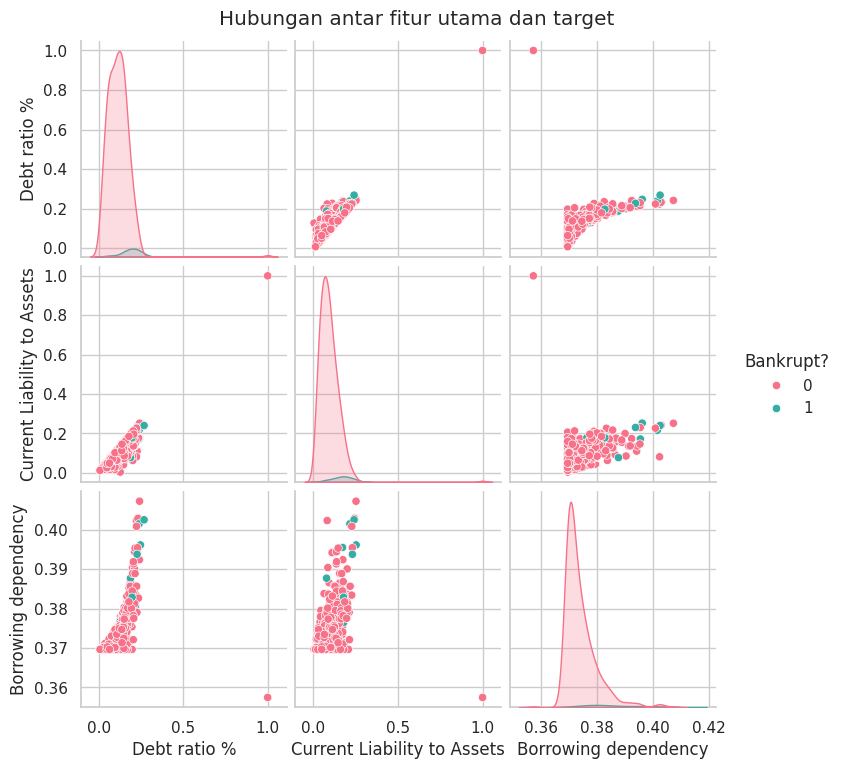

In [ ]:
# 📈 5. Pairplot untuk 3 fitur teratas (optional)
# ==========================================================
top3 = corr[1:4].index.tolist()  # ambil 3 fitur paling berkorelasi selain target
sns.pairplot(df.sample(500)[top3 + ['Bankrupt?']], hue='Bankrupt?', palette='husl')
plt.suptitle('Hubungan antar fitur utama dan target', y=1.02)
plt.show()

## Data Preparation

Distribusi awal (sebelum split): Counter({0: 6599, 1: 220})


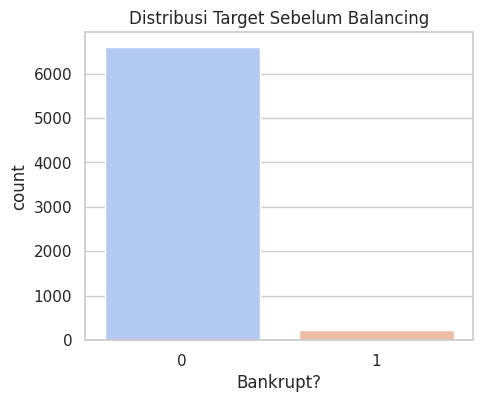

In [ ]:
# 1. Load Data
df.columns = df.columns.str.strip()

X = df.drop("Bankrupt?", axis=1)
y = df["Bankrupt?"]

# 2. Cek Keseimbangan Data Awal
print("Distribusi awal (sebelum split):", Counter(y))

plt.figure(figsize=(5,4))
sns.countplot(x='Bankrupt?', data=df, hue='Bankrupt?', palette='coolwarm', legend=False)
plt.title("Distribusi Target Sebelum Balancing")
plt.show()

In [ ]:
# 3. Split Train/Test (tanpa scaling & tanpa SMOTE)
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train distribusi:", Counter(y_train))
print("Test  distribusi:", Counter(y_test))

Train distribusi: Counter({0: 5279, 1: 176})
Test  distribusi: Counter({0: 1320, 1: 44})


In [ ]:
# 4. Scaling — hanya fit pada train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [ ]:
# 5. SMOTETomek — hanya diterapkan pada TRAIN
sm = SMOTETomek(random_state=RANDOM_STATE)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)

print("\nDistribusi kelas - sebelum SMOTETomek:", np.bincount(y_train))
print("Distribusi kelas - sesudah SMOTETomek:", np.bincount(y_train_res))


Distribusi kelas - sebelum SMOTETomek: [5279  176]
Distribusi kelas - sesudah SMOTETomek: [5278 5278]


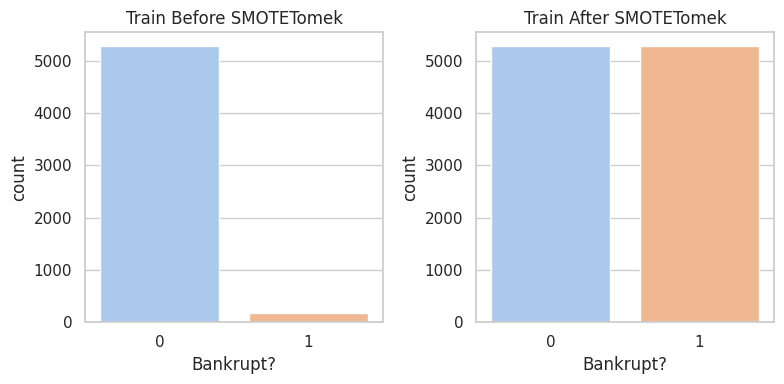

Calibration split OK.


In [ ]:
# 6. Visualisasi perubahan distribusi
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
sns.countplot(x=y_train, hue=y_train, palette='pastel', legend=False)
plt.title('Train Before SMOTETomek')

plt.subplot(1,2,2)
sns.countplot(x=y_train_res, hue=y_train_res, palette='pastel', legend=False)
plt.title('Train After SMOTETomek')

plt.tight_layout()
plt.show()

# 7. OPTIONAL: calibration split
X_tr_sub, X_cal_sub, y_tr_sub, y_cal_sub = train_test_split(
    X_train_res, y_train_res,
    test_size=0.2,
    stratify=y_train_res,
    random_state=RANDOM_STATE
)

print("Calibration split OK.")

## Modeling

In [ ]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced_subsample'),
    "Artificial Neural Network": MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500, random_state=42),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    )
}


🔹 Training model: Decision Tree

📊 Hasil evaluasi Decision Tree:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      1320
           1       0.26      0.45      0.33        44

    accuracy                           0.94      1364
   macro avg       0.62      0.71      0.65      1364
weighted avg       0.96      0.94      0.95      1364



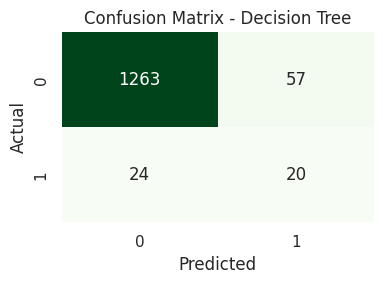


🔹 Training model: Random Forest

📊 Hasil evaluasi Random Forest:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1320
           1       0.39      0.59      0.47        44

    accuracy                           0.96      1364
   macro avg       0.69      0.78      0.72      1364
weighted avg       0.97      0.96      0.96      1364



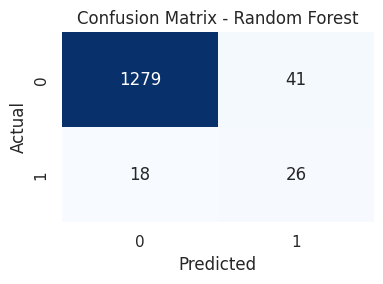


🔹 Training model: Artificial Neural Network

📊 Hasil evaluasi Artificial Neural Network:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1320
           1       0.38      0.41      0.40        44

    accuracy                           0.96      1364
   macro avg       0.68      0.69      0.69      1364
weighted avg       0.96      0.96      0.96      1364



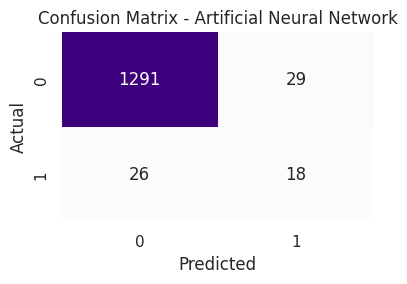


🔹 Training model: XGBoost

📊 Hasil evaluasi XGBoost:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1320
           1       0.38      0.64      0.48        44

    accuracy                           0.96      1364
   macro avg       0.69      0.80      0.73      1364
weighted avg       0.97      0.96      0.96      1364



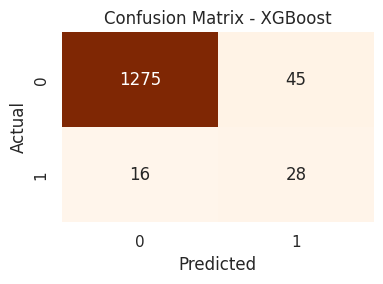


🔹 Training model: LightGBM
[LightGBM] [Info] Number of positive: 5278, number of negative: 5278
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011706 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 23735
[LightGBM] [Info] Number of data points in the train set: 10556, number of used features: 94
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

📊 Hasil evaluasi LightGBM:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1320
           1       0.53      0.57      0.55        44

    accuracy                           0.97      1364
   macro avg       0.76      0.78      0.77      1364
weighted avg       0.97      0.97      0.97      1364



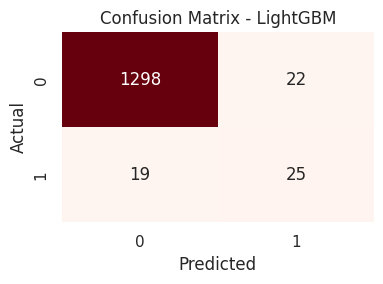

In [ ]:
# 2. Training + Evaluasi (versi dengan warna beda per model)

# Warna confusion matrix per model
cm_colors = {
    "Decision Tree": "Greens",
    "Random Forest": "Blues",
    "Artificial Neural Network": "Purples",
    "XGBoost": "Oranges",
    "LightGBM": "Reds"
}

results = []
for name, model in models.items():
    print(f"\n🔹 Training model: {name}")

    # Train pakai data balanced
    model.fit(X_train_res, y_train_res)

    # Predict pakai test original
    y_pred = model.predict(X_test_scaled)

    # ===== METRIK DASAR =====
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # ===== PROBABILITY =====
    try:
        y_score = model.predict_proba(X_test_scaled)[:, 1]
    except:
        y_score = None

    pr_auc = np.nan
    roc_auc = np.nan

    if y_score is not None:
        prec_vals, rec_vals, _ = precision_recall_curve(y_test, y_score)
        pr_auc = auc(rec_vals, prec_vals)
        roc_auc = roc_auc_score(y_test, y_score)

    # ===== SIMPAN RESULT =====
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "PR-AUC": pr_auc,
        "ROC-AUC": roc_auc
    })

    # ===== REPORT =====
    print(f"\n📊 Hasil evaluasi {name}:")
    print(classification_report(y_test, y_pred))

    # ===== CONFUSION MATRIX =====
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(4, 3))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=cm_colors.get(name, "Blues"),  # warna khusus berdasarkan model
        cbar=False
    )
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()


🏆 Hasil Akhir:


,Model,Accuracy,Precision,Recall,F1-Score,PR-AUC,ROC-AUC
4,LightGBM,0.969941,0.531915,0.568182,0.549451,0.532122,0.953013
3,XGBoost,0.955279,0.383562,0.636364,0.478632,0.469271,0.951136
1,Random Forest,0.956745,0.388060,0.590909,0.468468,0.446086,0.944318
2,Artificial Neural Network,0.959677,0.382979,0.409091,0.395604,0.300567,0.823037
0,Decision Tree,0.940616,0.259740,0.454545,0.330579,0.365941,0.705682



🏆 Model terbaik berdasarkan F1-Score adalah: LightGBM
[LightGBM] [Info] Number of positive: 5278, number of negative: 5278
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009933 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 23735
[LightGBM] [Info] Number of data points in the train set: 10556, number of used features: 94
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


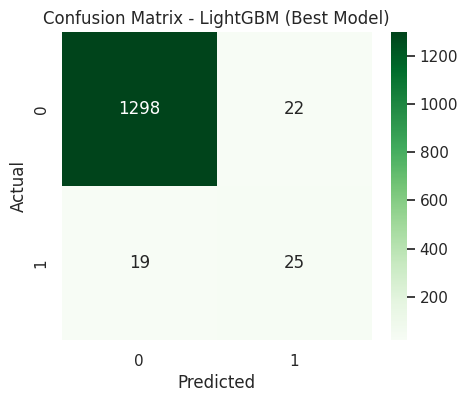

In [ ]:
# 3. Pilih model terbaik berdasarkan F1
results_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)

print("\n🏆 Hasil Akhir:")
display(results_df)

best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print(f"\n🏆 Model terbaik berdasarkan F1-Score adalah: {best_model_name}")

# ==== LATIH ULANG BEST MODEL ====
best_model.fit(X_train_res, y_train_res)

# ==== CONFUSION MATRIX BEST MODEL ====
y_pred_best = best_model.predict(X_test_scaled)
cm_best = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens')
plt.title(f'Confusion Matrix - {best_model_name} (Best Model)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Evaluasi

In [ ]:
print("Best model:", best_model_name)
print(best_model)

Best model: LightGBM
LGBMClassifier(learning_rate=0.05, n_estimators=300, random_state=42)


In [ ]:
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Asumsi: kamu sudah punya 'best_model', 'X_test', 'y_test' dari section sebelumnya
y_pred = best_model.predict(X_test_scaled)
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]


In [ ]:
# 📋 1. Classification Report (Precision, Recall, F1-Score)
# ==========================================================
print(f"\n📈 Evaluation Report untuk model terbaik: {best_model_name}\n")
report = classification_report(y_test, y_pred, target_names=['Sehat (0)', 'Bangkrut (1)'], output_dict=True)
report_df = pd.DataFrame(report).T
display(report_df)


📈 Evaluation Report untuk model terbaik: LightGBM



,precision,recall,f1-score,support
Sehat (0),0.985573,0.983333,0.984452,1320.000000
Bangkrut (1),0.531915,0.568182,0.549451,44.000000
accuracy,0.969941,0.969941,0.969941,0.969941
macro avg,0.758744,0.775758,0.766951,1364.000000
weighted avg,0.970939,0.969941,0.970420,1364.000000


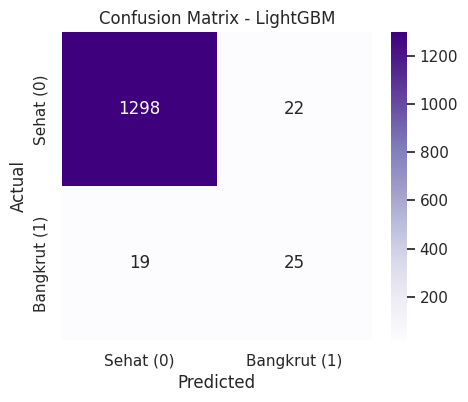

True Positive : 25
True Negative : 1298
False Positive: 22
False Negative: 19


In [ ]:
# 🧮 2. Confusion Matrix
# ==========================================================
cm = confusion_matrix(y_test, y_pred)
labels = ['Sehat (0)', 'Bangkrut (1)']

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=labels, yticklabels=labels)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Menampilkan metrik utama secara eksplisit
TP = cm[1,1]
TN = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]
print(f"True Positive : {TP}")
print(f"True Negative : {TN}")
print(f"False Positive: {FP}")
print(f"False Negative: {FN}")

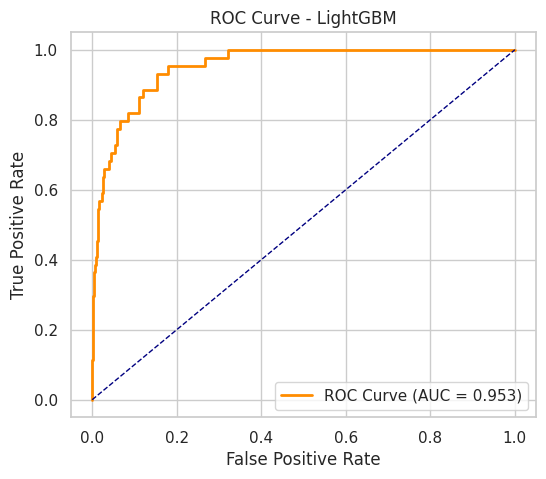

AUC Score: 0.9530


In [ ]:
# 🧠 3. ROC Curve & AUC (Area Under Curve)
# ==========================================================
if y_proba is not None:
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc_score:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {best_model_name}')
    plt.legend(loc="lower right")
    plt.show()

    print(f"AUC Score: {auc_score:.4f}")
else:
    print("Model ini tidak mendukung probabilitas, ROC Curve tidak dapat dihitung.")

In [ ]:
# 🧾 4. Ringkasan Evaluasi
# ==========================================================
print("\n🔹 Rangkuman Evaluasi Model Terbaik:")
summary = {
    "Model": best_model_name,
    "Accuracy": report['accuracy'],
    "Precision (Bangkrut)": report['Bangkrut (1)']['precision'],
    "Recall (Bangkrut)": report['Bangkrut (1)']['recall'],
    "F1-Score (Bangkrut)": report['Bangkrut (1)']['f1-score']
}
display(pd.DataFrame([summary]))


🔹 Rangkuman Evaluasi Model Terbaik:


,Model,Accuracy,Precision (Bangkrut),Recall (Bangkrut),F1-Score (Bangkrut)
0,LightGBM,0.969941,0.531915,0.568182,0.549451
